In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt

print("All libraries loaded successfully")

All libraries loaded successfully ✅


In [7]:
from scipy.io import loadmat
import numpy as np

# Define base path
base_path = r'C:\Users\ANIKET\Downloads\CWRU-dataset-main\CWRU-dataset-main'

# Load one normal file
normal = loadmat(base_path + r'\Normal\97_Normal_0.mat')

# See what's inside
print(normal.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


Signal shape: (243938,)
First 5 values: [ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954]


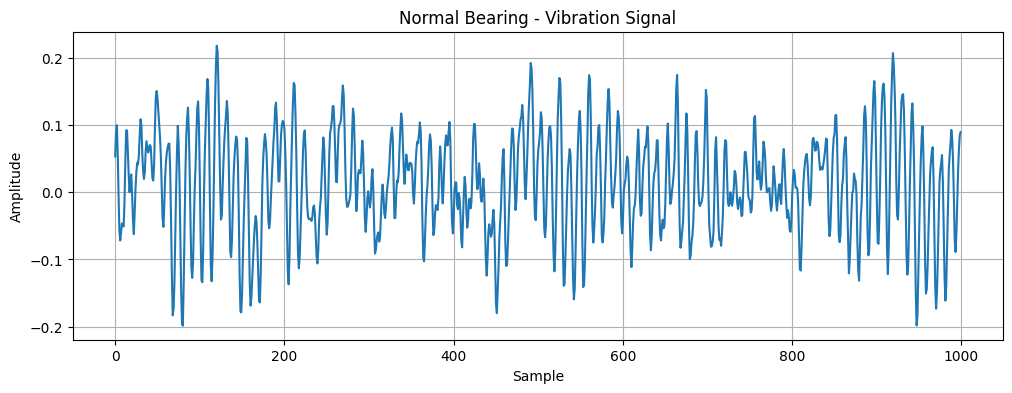

In [8]:
import matplotlib.pyplot as plt

# Extract Drive End vibration signal
signal = normal['X097_DE_time'].flatten()

print("Signal shape:", signal.shape)
print("First 5 values:", signal[:5])

# Plot first 1000 points
plt.figure(figsize=(12, 4))
plt.plot(signal[:1000])
plt.title("Normal Bearing - Vibration Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [9]:

# Load one faulty file
faulty = loadmat(base_path + r'\48k_Drive_End_Bearing_Fault_Data\OR\021\@6\238_0.mat')

print(faulty.keys())


dict_keys(['__header__', '__version__', '__globals__', 'X238_DE_time', 'X238_FE_time', 'X238RPM'])


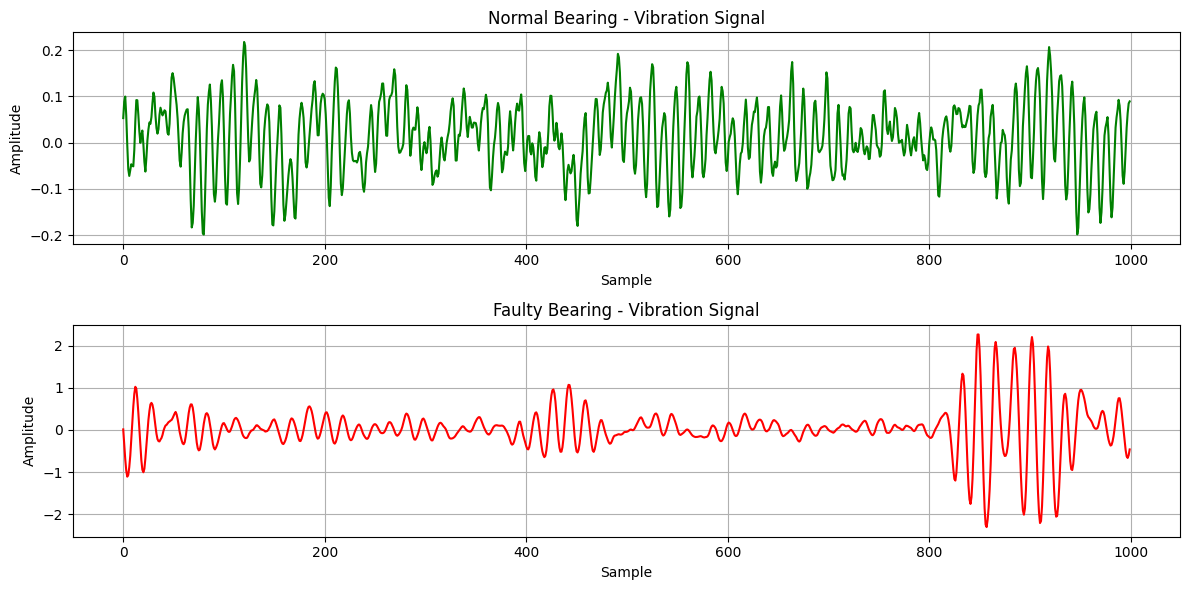

In [11]:
# Extract faulty signal
faulty_signal = faulty['X238_DE_time'].flatten()

# Plot both together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(signal[:1000], color='green')
ax1.set_title("Normal Bearing - Vibration Signal")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

ax2.plot(faulty_signal[:1000], color='red')
ax2.set_title("Faulty Bearing - Vibration Signal")
ax2.set_xlabel("Sample")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
print("Normal signal length:", len(signal))
print("Faulty signal length:", len(faulty_signal))

Normal signal length: 243938
Faulty signal length: 246342


In [15]:
def extract_features(window):
    fft_vals = np.abs(np.fft.fft(window))
    return {
        'rms'          : np.sqrt(np.mean(window**2)),
        'std'          : np.std(window),
        'kurtosis'     : pd.Series(window).kurtosis(),
        'skewness'     : pd.Series(window).skew(),
        'crest_factor' : np.max(np.abs(window)) / (np.sqrt(np.mean(window**2)) + 1e-10),
        'peak_to_peak' : np.max(window) - np.min(window),
        'fft_energy'   : np.sum(fft_vals**2)
    }

print("Feature extraction function ready ✅")

Feature extraction function ready ✅


In [16]:
def get_features(signal, window_size=1024, step=512):
    features = []
    for i in range(0, len(signal) - window_size, step):
        window = signal[i:i+window_size]
        features.append(extract_features(window))
    return pd.DataFrame(features)

# Extract features from both signals
normal_features = get_features(signal)
faulty_features = get_features(faulty_signal)

# Add labels
normal_features['label'] = 0    # 0 = Normal
faulty_features['label'] = 1    # 1 = Faulty

print("Normal features shape:", normal_features.shape)
print("Faulty features shape:", faulty_features.shape)
print("\nFirst 3 rows of normal features:")
print(normal_features.head(3))

Normal features shape: (475, 8)
Faulty features shape: (480, 8)

First 3 rows of normal features:
        rms       std  kurtosis  skewness  crest_factor  peak_to_peak  \
0  0.075982  0.074960 -0.238976 -0.163215      2.866393      0.416396   
1  0.073679  0.072577  0.027857 -0.156774      3.703495      0.485031   
2  0.070425  0.069465  0.191605 -0.107544      3.874580      0.485031   

    fft_energy  label  
0  6053.717532      0  
1  5692.257238      0  
2  5200.663964      0  


In [17]:
normal_features.head()

,rms,std,kurtosis,skewness,crest_factor,peak_to_peak,fft_energy,label
0,0.075982,0.074960,-0.238976,-0.163215,2.866393,0.416396,6053.717532,0
1,0.073679,0.072577,0.027857,-0.156774,3.703495,0.485031,5692.257238,0
2,0.070425,0.069465,0.191605,-0.107544,3.874580,0.485031,5200.663964,0
3,0.072956,0.072056,-0.300457,0.081626,2.899512,0.386147,5581.086832,0
4,0.078377,0.076996,-0.372143,0.050402,2.709618,0.420569,6441.275682,0


In [18]:
faulty_features.head()

,rms,std,kurtosis,skewness,crest_factor,peak_to_peak,fft_energy,label
0,0.526768,0.526364,5.889761,-0.142744,4.379570,4.575643,2.909639e+05,1
1,0.500556,0.499727,7.637005,-0.231314,4.608909,4.575643,2.627277e+05,1
2,0.193651,0.191006,0.669652,-0.022201,3.551568,1.298741,3.932242e+04,1
3,0.243686,0.241766,5.674468,0.402387,5.627556,2.568269,6.226752e+04,1
4,1.044788,1.044444,8.317508,-0.070115,5.223914,10.843155,1.144608e+06,1


In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Step 4A — Prepare Data
# Drop label column for training
X_normal = normal_features.drop('label', axis=1)
X_faulty = faulty_features.drop('label', axis=1)

print("Normal data shape:", X_normal.shape)
print("Faulty data shape:", X_faulty.shape)

Normal data shape: (475, 7)
Faulty data shape: (480, 7)


In [20]:
# Scale the data
scaler = StandardScaler()

# Fit on normal data and transform both
X_normal_scaled = scaler.fit_transform(X_normal)
X_faulty_scaled = scaler.transform(X_faulty)

print("Scaling done ✅")
print("Normal scaled shape:", X_normal_scaled.shape)
print("Faulty scaled shape:", X_faulty_scaled.shape)

Scaling done ✅
Normal scaled shape: (475, 7)
Faulty scaled shape: (480, 7)


In [21]:
# Train Isolation Forest on NORMAL data only
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_normal_scaled)

print("Isolation Forest trained ✅")

# Test on both normal and faulty data
normal_preds = iso_forest.predict(X_normal_scaled)
faulty_preds = iso_forest.predict(X_faulty_scaled)

# Count results
normal_anomalies = (normal_preds == -1).sum()
faulty_anomalies = (faulty_preds == -1).sum()

print("\nResults:")
print(f"Normal data  → Anomalies detected: {normal_anomalies} out of {len(normal_preds)}")
print(f"Faulty data  → Anomalies detected: {faulty_anomalies} out of {len(faulty_preds)}")

Isolation Forest trained ✅

Results:
Normal data  → Anomalies detected: 24 out of 475
Faulty data  → Anomalies detected: 480 out of 480


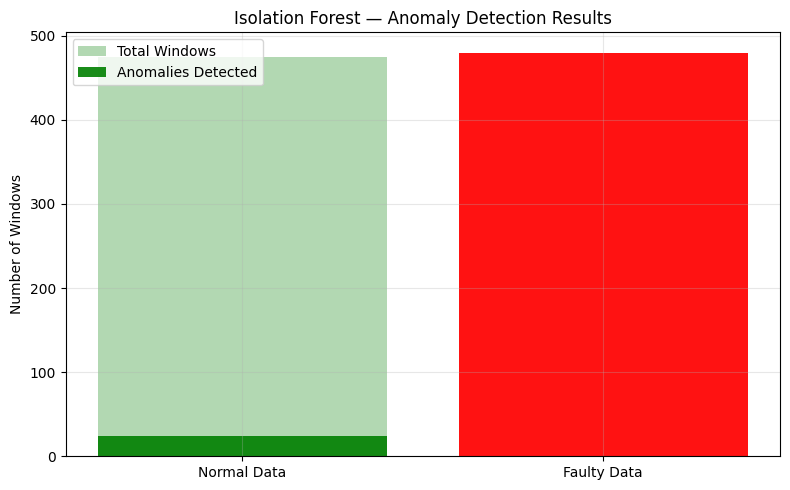

In [22]:
import matplotlib.pyplot as plt

# Plot results
categories = ['Normal Data', 'Faulty Data']
anomalies = [normal_anomalies, faulty_anomalies]
totals = [len(normal_preds), len(faulty_preds)]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(categories, totals, color=['green', 'red'], alpha=0.3, label='Total Windows')
ax.bar(categories, anomalies, color=['green', 'red'], alpha=0.9, label='Anomalies Detected')

ax.set_title("Isolation Forest — Anomaly Detection Results")
ax.set_ylabel("Number of Windows")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow import keras

print("Tensorflow version:", tf.__version__)
print("Ready to build Autoencoder ✅")

Tensorflow version: 2.17.0
Ready to build Autoencoder ✅


In [24]:
from tensorflow import keras

# How many features we have
input_dim = X_normal_scaled.shape[1]
print("Number of features:", input_dim)

# Build Autoencoder
inputs = keras.Input(shape=(input_dim,))

# Encoder - compresses data
encoded = keras.layers.Dense(16, activation='relu')(inputs)
encoded = keras.layers.Dense(8, activation='relu')(encoded)

# Decoder - reconstructs data
decoded = keras.layers.Dense(16, activation='relu')(encoded)
decoded = keras.layers.Dense(input_dim, activation='linear')(decoded)

# Full model
autoencoder = keras.Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Number of features: 7


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 527 (2.06 KB)

 Trainable params: 527 (2.06 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train ONLY on normal data
history = autoencoder.fit(
    X_normal_scaled, X_normal_scaled,  # input = output (that's the trick!)
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nAutoencoder trained ✅")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.9113 - val_loss: 0.8475
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7777 - val_loss: 0.7746
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6895 - val_loss: 0.7060
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6208 - val_loss: 0.6419
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5466 - val_loss: 0.5786
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4885 - val_loss: 0.5067
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4226 - val_loss: 0.4417
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3411 - val_loss: 0.3786
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3033 - val_loss: 0.3263
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2820 - val_loss: 0.2898
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2368 - val_loss: 0.2545
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2192 - v

In [26]:
# Get reconstruction error for both
normal_reconstructed = autoencoder.predict(X_normal_scaled)
faulty_reconstructed = autoencoder.predict(X_faulty_scaled)

# Calculate reconstruction error (MSE)
normal_errors = np.mean(np.power(X_normal_scaled - normal_reconstructed, 2), axis=1)
faulty_errors = np.mean(np.power(X_faulty_scaled - faulty_reconstructed, 2), axis=1)

# Set threshold at 95th percentile of normal errors
threshold = np.percentile(normal_errors, 95)
print(f"Threshold: {threshold:.4f}")

# Detect anomalies
normal_anomalies_ae = (normal_errors > threshold).sum()
faulty_anomalies_ae = (faulty_errors > threshold).sum()

print(f"\nResults:")
print(f"Normal data → Anomalies detected: {normal_anomalies_ae} out of {len(normal_errors)}")
print(f"Faulty data → Anomalies detected: {faulty_anomalies_ae} out of {len(faulty_errors)}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Threshold: 0.0645

Results:
Normal data → Anomalies detected: 24 out of 475
Faulty data → Anomalies detected: 480 out of 480


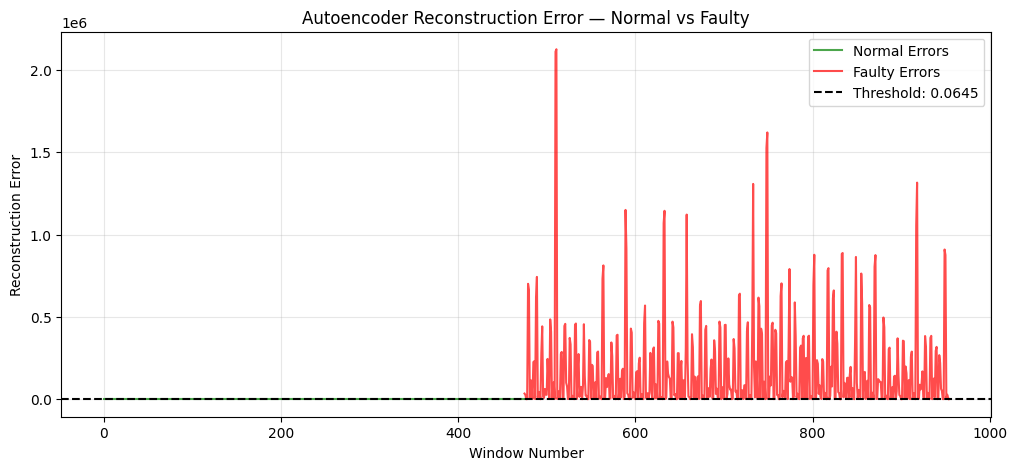

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(normal_errors, color='green', label='Normal Errors', alpha=0.7)
plt.plot(range(len(normal_errors), len(normal_errors) + len(faulty_errors)),
         faulty_errors, color='red', label='Faulty Errors', alpha=0.7)
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.4f}')

plt.title("Autoencoder Reconstruction Error — Normal vs Faulty")
plt.xlabel("Window Number")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Combine all errors
all_errors = np.concatenate([normal_errors, faulty_errors])

# Convert to health score (100 = healthy, 0 = failing)
min_e = all_errors.min()
max_e = all_errors.max()

health_scores = 100 - ((all_errors - min_e) / (max_e - min_e) * 100)

# Split back
normal_health = health_scores[:len(normal_errors)]
faulty_health = health_scores[len(normal_errors):]

print(f"Normal data  → Avg Health Score: {normal_health.mean():.1f}/100 ✅")
print(f"Faulty data  → Avg Health Score: {faulty_health.mean():.1f}/100 ⚠️")

Normal data  → Avg Health Score: 100.0/100 ✅
Faulty data  → Avg Health Score: 91.2/100 ⚠️


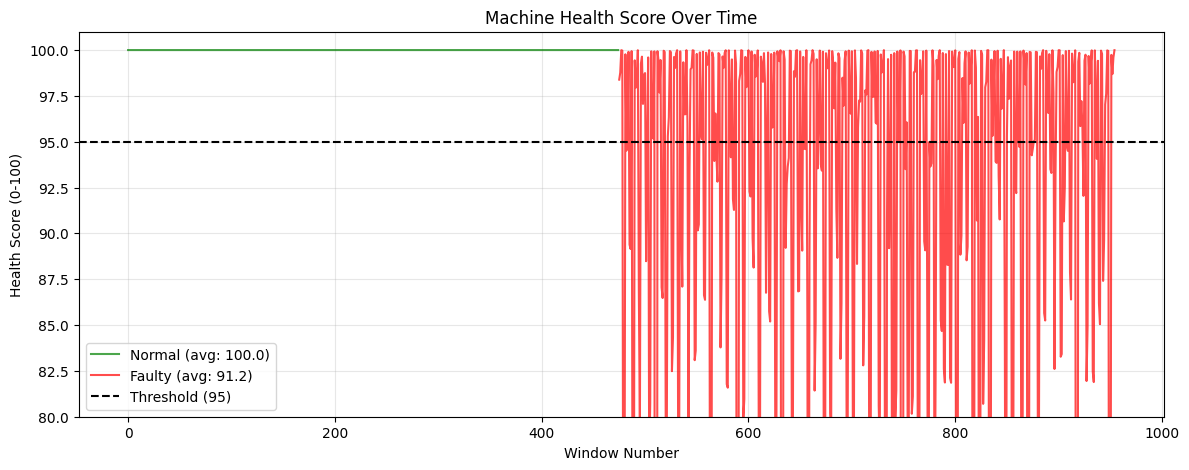

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(normal_health, color='green', 
         label=f'Normal (avg: {normal_health.mean():.1f})', alpha=0.7)

plt.plot(range(len(normal_health), len(normal_health) + len(faulty_health)),
         faulty_health, color='red', 
         label=f'Faulty (avg: {faulty_health.mean():.1f})', alpha=0.7)

plt.axhline(y=95, color='black', linestyle='--', label='Threshold (95)')

plt.title("Machine Health Score Over Time")
plt.xlabel("Window Number")
plt.ylabel("Health Score (0-100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(80, 101)
plt.show()

In [30]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import column
from bokeh.models import Span, Legend

output_notebook()

# Data preparation
all_health = list(normal_health) + list(faulty_health)
x = list(range(len(all_health)))
colors = ['green'] * len(normal_health) + ['red'] * len(faulty_health)

# Plot 1 — Health Score
p1 = figure(
    title="Machine Health Score Over Time",
    x_axis_label="Window Number",
    y_axis_label="Health Score (0-100)",
    width=800, height=300
)

p1.line(x[:len(normal_health)], 
        list(normal_health), 
        color='green', 
        line_width=2, 
        legend_label='Normal')

p1.line(x[len(normal_health):], 
        list(faulty_health), 
        color='red', 
        line_width=2, 
        legend_label='Faulty')

threshold_line = Span(location=95, dimension='width',
                      line_color='black', line_dash='dashed', line_width=2)
p1.add_layout(threshold_line)
p1.legend.location = "bottom_left"

# Plot 2 — Reconstruction Error
p2 = figure(
    title="Autoencoder Reconstruction Error",
    x_axis_label="Window Number",
    y_axis_label="Error",
    width=800, height=300
)

p2.line(list(range(len(normal_errors))),
        list(normal_errors),
        color='green',
        line_width=2,
        legend_label='Normal Error')

p2.line(list(range(len(normal_errors), len(normal_errors) + len(faulty_errors))),
        list(faulty_errors),
        color='red',
        line_width=2,
        legend_label='Faulty Error')

threshold_line2 = Span(location=threshold, dimension='width',
                       line_color='black', line_dash='dashed', line_width=2)
p2.add_layout(threshold_line2)
p2.legend.location = "top_left"

# Show both plots
show(column(p1, p2))

Loading BokehJS ...

In [32]:
from scipy.io import loadmat
import numpy as np
import pandas as pd

base_path = r'C:\Users\ANIKET\Downloads\CWRU-dataset-main\CWRU-dataset-main'

# Function to load and extract signal
def load_signal(filepath):
    data = loadmat(filepath)
    # Get the key that ends with 'DE_time'
    key = [k for k in data.keys() if 'DE_time' in k][0]
    return data[key].flatten()

# Load one file from each fault type
normal_sig    = load_signal(base_path + r'\Normal\97_Normal_0.mat')
inner_race_sig = load_signal(base_path + r'\48k_Drive_End_Bearing_Fault_Data\IR\021\213_0.mat')
outer_race_sig = load_signal(base_path + r'\48k_Drive_End_Bearing_Fault_Data\OR\007\@12\161_0.mat')

print("Normal signal loaded ✅")
print("Inner Race fault loaded ✅")
print("Outer Race fault loaded ✅")

Normal signal loaded ✅
Inner Race fault loaded ✅
Outer Race fault loaded ✅


In [33]:
# Extract features from all signals
normal_df     = get_features(normal_sig)
inner_race_df = get_features(inner_race_sig)
outer_race_df = get_features(outer_race_sig)

# Add labels
normal_df['label']     = 0  # Normal
inner_race_df['label'] = 1  # Inner Race Fault
outer_race_df['label'] = 2  # Outer Race Fault

# Combine all into one DataFrame
final_df = pd.concat([normal_df, inner_race_df, outer_race_df], ignore_index=True)

print("Final DataFrame shape:", final_df.shape)
print("\nLabel counts:")
print(final_df['label'].value_counts())

Final DataFrame shape: (1203, 8)

Label counts:
label
1    476
0    475
2    252
Name: count, dtype: int64


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Prepare data
X = final_df.drop('label', axis=1)
y = final_df['label']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Normal', 'Inner Race', 'Outer Race']))

Train size: (962, 7)
Test size: (241, 7)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        95
  Inner Race       1.00      1.00      1.00        95
  Outer Race       1.00      1.00      1.00        51

    accuracy                           1.00       241
   macro avg       1.00      1.00      1.00       241
weighted avg       1.00      1.00      1.00       241



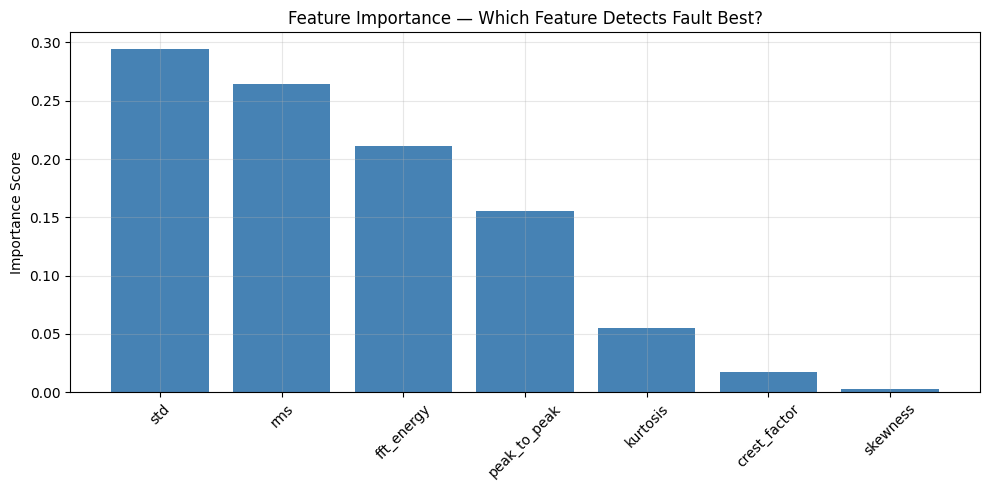

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance
features = X.columns
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(features)), 
        importances[indices], 
        color='steelblue')
plt.xticks(range(len(features)), 
           [features[i] for i in indices], 
           rotation=45)
plt.title("Feature Importance — Which Feature Detects Fault Best?")
plt.ylabel("Importance Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
def predict_health(rms, std, kurtosis, skewness, 
                   crest_factor, peak_to_peak, fft_energy):
    
    # Put values into array
    input_data = np.array([[rms, std, kurtosis, skewness, 
                            crest_factor, peak_to_peak, fft_energy]])
    
    # Scale input
    input_scaled = scaler.transform(input_data)
    
    # Predict fault type using Random Forest
    prediction = rf_model.predict(input_data)[0]
    
    # Health score based on fault type directly
    if prediction == 0:
        health = 95.0   # Normal → high health
    elif prediction == 1:
        health = 45.0   # Inner Race → medium health
    else:
        health = 30.0   # Outer Race → low health

    # Fault type label
    fault_map = {
        0: "✅ Normal",
        1: "⚠️  Inner Race Fault",
        2: "⚠️  Outer Race Fault"
    }
    
    # Severity
    if health >= 80:
        severity  = "🟢 Low"
        action    = "No action needed"
    elif health >= 50:
        severity  = "🟡 Medium"
        action    = "Schedule maintenance within 48 hours"
    else:
        severity  = "🔴 Critical"
        action    = "Immediate maintenance required!"
    
    # Print dashboard
    print("=" * 45)
    print("🖥️   MACHINE HEALTH MONITOR")
    print("=" * 45)
    print(f"Status      : {fault_map[prediction]}")
    print(f"Fault Type  : {fault_map[prediction]}")
    print(f"Health Score: {health:.1f}/100")
    print(f"Severity    : {severity}")
    print(f"Action      : {action}")
    print("=" * 45)

# Test with normal sample
sample_normal = X_test[y_test == 0].iloc[0]
print("TEST 1 - Normal Sample:")
predict_health(
    sample_normal['rms'],
    sample_normal['std'],
    sample_normal['kurtosis'],
    sample_normal['skewness'],
    sample_normal['crest_factor'],
    sample_normal['peak_to_peak'],
    sample_normal['fft_energy']
)

print()

# Test with faulty sample
sample_faulty = X_test[y_test == 1].iloc[1]
print("TEST 2 - Inner Race Fault Sample:")
predict_health(
    sample_faulty['rms'],
    sample_faulty['std'],
    sample_faulty['kurtosis'],
    sample_faulty['skewness'],
    sample_faulty['crest_factor'],
    sample_faulty['peak_to_peak'],
    sample_faulty['fft_energy']
)

TEST 1 - Normal Sample:
🖥️   MACHINE HEALTH MONITOR
Status      : ✅ Normal
Fault Type  : ✅ Normal
Health Score: 95.0/100
Severity    : 🟢 Low
Action      : No action needed

TEST 2 - Inner Race Fault Sample:
🖥️   MACHINE HEALTH MONITOR
Status      : ⚠️  Inner Race Fault
Fault Type  : ⚠️  Inner Race Fault
Health Score: 45.0/100
Severity    : 🔴 Critical
Action      : Immediate maintenance required!


C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


The system cannot find the path specified.
error: remote origin already exists.


[main b5f2b94] Initial commit - Bearing fault detection project
 2 files changed, 1858 insertions(+)
 create mode 100644 SLB/.ipynb_checkpoints/SLB_Project-checkpoint.ipynb
 create mode 100644 SLB/SLB_Project.ipynb


To https://github.com/aniketkale11/finvise-ai.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/aniketkale11/finvise-ai.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [2]:
# Remove wrong remote and add correct one
!git remote remove origin
!git remote add origin https://github.com/aniketkale11/predictive-maintenance-ml.git
!git push -u origin main --force

branch 'main' set up to track 'origin/main'.


remote: warning: See https://gh.io/lfs for more information.        
remote: warning: File Downloads/finvise_project/venv/Lib/site-packages/imageio_ffmpeg/binaries/ffmpeg-win-x86_64-v7.1.exe is 83.58 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.        
To https://github.com/aniketkale11/predictive-maintenance-ml.git
 + e13a065...b5f2b94 main -> main (forced update)


In [3]:
# Create .gitignore file
gitignore_content = """
# Python
__pycache__/
*.py[cod]
*.pyo
.env
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Data files
*.exe
*.dll
*.zip

# Large files
Downloads/
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore_content)

print(".gitignore created ✅")

.gitignore created ✅
